# Imports

In [104]:
import pandas as pd
import json
import re
import os
from pathlib import Path
import pandas as pd


# Load results

## Load invalid rows

In [105]:
df = pd.read_csv('/Users/lockewang/FIG/WebDomainRandomizer/data/baseline_results_full_new_cleaned.csv')
clean = pd.read_csv('baseline_results_full_new_cleaned.csv', usecols=['interesting_cases'])
assert len(df) == len(clean), "Original and cleaned CSV row counts must match"
df['interesting_cases'] = clean['interesting_cases'].values
display(df['interesting_cases'].value_counts())
df = df[df['interesting_cases'] != 'Invalid'].copy()

interesting_cases
Invalid              1872
Clickable areas       673
False heuristics      384
Visual context        192
Spatial relations      96
Name: count, dtype: int64

## baseline results

In [106]:
# Load file
RESULT_FOLDER_PATH = "/Users/lockewang/FIG/WebDomainRandomizer/baseline_results_full_new/baseline_results"

# load predictions from jsonl files for each model, reasoning_type, query_type combo into one dataframe
# Find all .jsonl files in the result folder
jsonl_files = sorted(list(Path(RESULT_FOLDER_PATH).glob("*.jsonl")))
print(f"Found {len(jsonl_files)} .jsonl files")

# Load all jsonl files into a list of dataframes
dataframes = {}
for jsonl_file in jsonl_files:
    print(f"Loading {jsonl_file.name}")
    df_baseline = pd.read_json(jsonl_file, lines=True)
    dataframes[jsonl_file.name] = df_baseline

# Stitch together re-runs due to the `nan` relational query error at row 1625.
configs = [
    ("predictions_uitars15_no_reasoning_direct_query_20251213_223027", "predictions_uitars15_no_reasoning_direct_query_20251215_024416", "replace"),
    ("predictions_uitars15_no_reasoning_relational_query_20251213_222956", "predictions_uitars15_no_reasoning_relational_query_20251215_024414", "replace"),
    ("predictions_uitars15_reasoning_direct_query_20251213_223013", "predictions_uitars15_reasoning_direct_query_20251215_024415", "replace"),
    ("predictions_uitars15_reasoning_relational_query_20251213_222938", "predictions_uitars15_reasoning_relational_query_20251215_024412", "replace")
]

for config in configs:
    big_df = dataframes[config[0]+".jsonl"].copy()
    small_df = dataframes[config[1]+".jsonl"].copy()
    if config[2] == "replace":
        big_df.iloc[-92:] = small_df.values
    elif config[2] == "concat":
        big_df = pd.concat([big_df, small_df], ignore_index=True)

    print(f"config: {config}")
    print(f"len(big_df): {len(big_df)}")
    df_baseline = pd.concat([df_baseline, big_df], ignore_index=True)

"""
Processing predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl (1/20)
1716
Processing predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl (2/20)
1716
Processing predictions_gta1_reasoning_direct_query_20251214_220400.jsonl (3/20)
1716
Processing predictions_gta1_reasoning_relational_query_20251214_220417.jsonl (4/20)
1716

Processing predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl (5/20)
1716
Processing predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl (6/20)
92

Processing predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl (7/20)
1624
Processing predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl (8/20)
92

Processing predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl (9/20)
1716
Processing predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl (10/20)
92

Processing predictions_qwen25vl_reasoning_relational_query_20251214_022344.jsonl (11/20)
1624
Processing predictions_qwen25vl_reasoning_relational_query_20251215_021829.jsonl (12/20)
92

Processing predictions_uitars15_no_reasoning_direct_query_20251213_223027.jsonl (13/20)
1716
Processing predictions_uitars15_no_reasoning_direct_query_20251215_024416.jsonl (14/20)
92

Processing predictions_uitars15_no_reasoning_relational_query_20251213_222956.jsonl (15/20)
1716
Processing predictions_uitars15_no_reasoning_relational_query_20251215_024414.jsonl (16/20)
92

Processing predictions_uitars15_reasoning_direct_query_20251213_223013.jsonl (17/20)
1716
Processing predictions_uitars15_reasoning_direct_query_20251215_024415.jsonl (18/20)
92

Processing predictions_uitars15_reasoning_relational_query_20251213_222938.jsonl (19/20)
1716
Processing predictions_uitars15_reasoning_relational_query_20251215_024412.jsonl (20/20)
92

"""


Found 20 .jsonl files
Loading predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl
Loading predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl
Loading predictions_gta1_reasoning_direct_query_20251214_220400.jsonl
Loading predictions_gta1_reasoning_relational_query_20251214_220417.jsonl
Loading predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl
Loading predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl
Loading predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl
Loading predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl
Loading predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl
Loading predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl
Loading predictions_qwen25vl_reasoning_relational_query_20251214_022344.jsonl
Loading predictions_qwen25vl_reasoning_relational_query_20251215_021829.jsonl
Loading predictions_uitars15_no_reasoning_direct_query_20251213_

'\nProcessing predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl (1/20)\n1716\nProcessing predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl (2/20)\n1716\nProcessing predictions_gta1_reasoning_direct_query_20251214_220400.jsonl (3/20)\n1716\nProcessing predictions_gta1_reasoning_relational_query_20251214_220417.jsonl (4/20)\n1716\n\nProcessing predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl (5/20)\n1716\nProcessing predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl (6/20)\n92\n\nProcessing predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl (7/20)\n1624\nProcessing predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl (8/20)\n92\n\nProcessing predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl (9/20)\n1716\nProcessing predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl (10/20)\n92\n\nProcessing predictions_qwen25vl_reasoning_relational_query_2025121

## 6.5k & 25k perturbed data 3 epochs perturbed eval results

In [107]:
import json
import re
import os
from pathlib import Path
import pandas as pd

FINETUNED_RESULT_FOLDER_PATH = "/Users/lockewang/FIG/WebDomainRandomizer/final_model_all_results"

# load predictions from jsonl files for each model, reasoning_type, query_type combo into one dataframe
# Find all .jsonl files in the result folder
jsonl_files = sorted(list(Path(FINETUNED_RESULT_FOLDER_PATH).glob("*.jsonl")))
print(f"Found {len(jsonl_files)} .jsonl files")

# Load all jsonl files into a list of dataframes
dataframes = {}
for jsonl_file in jsonl_files:
    print(f"Loading {jsonl_file.name}")
    df = pd.read_json(jsonl_file, lines=True)
    dataframes[jsonl_file.name] = df

model_style_files =[
    'predictions_uitars15_no_reasoning_direct_query_20260109_033744.jsonl',
    'predictions_uitars15_no_reasoning_relational_query_20260109_033741.jsonl',
    'predictions_uitars15_reasoning_direct_query_20260109_033743.jsonl',
    'predictions_uitars15_reasoning_relational_query_20260109_033734.jsonl'
]
model_all_files = [
    'predictions_uitars15_no_reasoning_direct_query_20260109_204302.jsonl',
    'predictions_uitars15_no_reasoning_relational_query_20260109_204303.jsonl',
    'predictions_uitars15_reasoning_direct_query_20260109_204302.jsonl',
    'predictions_uitars15_reasoning_relational_query_20260109_204305.jsonl'
]
model_text_shrink_files = [
    'predictions_uitars15_no_reasoning_direct_query_20260110_005249.jsonl',
    'predictions_uitars15_no_reasoning_relational_query_20260110_005246.jsonl',
    'predictions_uitars15_reasoning_direct_query_20260110_005248.jsonl',
    'predictions_uitars15_reasoning_relational_query_20260110_005244.jsonl'
]

model_25k_3_epoch_files = [
    'predictions_uitars15_no_reasoning_direct_query_20260108_203457.jsonl',
    'predictions_uitars15_no_reasoning_relational_query_20260108_203520.jsonl',
    'predictions_uitars15_reasoning_direct_query_20260108_203518.jsonl',
    'predictions_uitars15_reasoning_relational_query_20260108_203521.jsonl'
]


model_all_df = pd.concat([dataframes[file] for file in model_all_files], ignore_index=True)
model_style_df = pd.concat([dataframes[file] for file in model_style_files], ignore_index=True)
model_text_shrink_df = pd.concat([dataframes[file] for file in model_text_shrink_files], ignore_index=True)
model_all_high_rank_df = pd.concat([dataframes[file] for file in model_25k_3_epoch_files], ignore_index=True)

model_all_df['model'] = 'all'
model_style_df['model'] = 'style'
model_text_shrink_df['model'] = 'text_shrink_zoom'
model_all_high_rank_df['model'] = 'all_25k_3_epoch'
df_baseline['model'] = 'baseline'

# Concatenate all dataframes
df_all = pd.concat([model_all_df, model_style_df, model_text_shrink_df, model_all_high_rank_df], ignore_index=True)



Found 16 .jsonl files
Loading predictions_uitars15_no_reasoning_direct_query_20260108_203457.jsonl
Loading predictions_uitars15_no_reasoning_direct_query_20260109_033744.jsonl
Loading predictions_uitars15_no_reasoning_direct_query_20260109_204302.jsonl
Loading predictions_uitars15_no_reasoning_direct_query_20260110_005249.jsonl
Loading predictions_uitars15_no_reasoning_relational_query_20260108_203520.jsonl
Loading predictions_uitars15_no_reasoning_relational_query_20260109_033741.jsonl
Loading predictions_uitars15_no_reasoning_relational_query_20260109_204303.jsonl
Loading predictions_uitars15_no_reasoning_relational_query_20260110_005246.jsonl
Loading predictions_uitars15_reasoning_direct_query_20260108_203518.jsonl
Loading predictions_uitars15_reasoning_direct_query_20260109_033743.jsonl
Loading predictions_uitars15_reasoning_direct_query_20260109_204302.jsonl
Loading predictions_uitars15_reasoning_direct_query_20260110_005248.jsonl
Loading predictions_uitars15_reasoning_relational_

## 25k salesforce data 1 epoch perturbed eval results

In [108]:
# Load 25k Salesforce (1 epoch) perturbed eval results — all jsonl from folder, then add to df_all
SALESFORCE_RESULTS_DIR = Path("/Users/lockewang/FIG/WebDomainRandomizer/exp_2_salesforce_1_epoch_results")
jsonl_files = sorted(list(SALESFORCE_RESULTS_DIR.glob("*.jsonl")))
print(f"Found {len(jsonl_files)} .jsonl files in {SALESFORCE_RESULTS_DIR}")
# Load every jsonl file into a list of dataframes, then concat once
salesforce_dfs = []
for jsonl_file in jsonl_files:
    print(f"Loading {jsonl_file.name}")
    salesforce_dfs.append(pd.read_json(jsonl_file, lines=True))
df_25k_salesforce_1_epoch = pd.concat(salesforce_dfs, ignore_index=True)
df_25k_salesforce_1_epoch['model'] = '25k_salesforce_1_epoch'
print(f"25k salesforce total rows: {len(df_25k_salesforce_1_epoch)}")
df_all = pd.concat([df_all, df_25k_salesforce_1_epoch], ignore_index=True)

Found 4 .jsonl files in /Users/lockewang/FIG/WebDomainRandomizer/exp_2_salesforce_1_epoch_results
Loading predictions_uitars15_no_reasoning_direct_query_20260218_083425.jsonl
Loading predictions_uitars15_no_reasoning_relational_query_20260218_083414.jsonl
Loading predictions_uitars15_reasoning_direct_query_20260218_083415.jsonl
Loading predictions_uitars15_reasoning_relational_query_20260218_083413.jsonl
25k salesforce total rows: 6864


## 25k perturbed data 1 epoch perturbed eval results

In [109]:
jsonl_files = sorted(list(Path("/Users/lockewang/FIG/WebDomainRandomizer/exp_2_checkpoint_1_epoch_results/").glob("*.jsonl")))
print(f"Found {len(jsonl_files)} .jsonl files")

# Load all jsonl files into a list of dataframes
df_25k_perturbed_1_epoch_results = pd.DataFrame()
for jsonl_file in jsonl_files:
    print(f"Loading {jsonl_file.name}")
    df = pd.read_json(jsonl_file, lines=True)
    df_25k_perturbed_1_epoch_results = pd.concat([df_25k_perturbed_1_epoch_results, df], ignore_index=True)

df_25k_perturbed_1_epoch_results['model'] = '25k_perturbed_1_epoch'
df_all = pd.concat([df_all, df_25k_perturbed_1_epoch_results], ignore_index=True)

Found 4 .jsonl files
Loading predictions_uitars15_no_reasoning_direct_query_20260207_185119.jsonl
Loading predictions_uitars15_no_reasoning_relational_query_20260207_185116.jsonl
Loading predictions_uitars15_reasoning_direct_query_20260207_185117.jsonl
Loading predictions_uitars15_reasoning_relational_query_20260207_185114.jsonl


# Filter invalid samples for perturbation eval results

# Parse action & calculate hit rate for all results

In [110]:
import math

IMAGE_FACTOR = 28
MIN_PIXELS = 100 * 28 * 28
MAX_PIXELS = 16384 * 28 * 28
MAX_RATIO = 200
IMAGE_HEIGHT = 1080
IMAGE_WIDTH = 1920

def escape_single_quotes(text):
    # 匹配未转义的单引号（不匹配 \\'）
    pattern = r"(?<!\\)'"
    return re.sub(pattern, r"\\'", text)

def round_by_factor(number: int, factor: int) -> int:
    """Returns the closest integer to 'number' that is divisible by 'factor'."""
    return round(number / factor) * factor


def ceil_by_factor(number: int, factor: int) -> int:
    """Returns the smallest integer greater than or equal to 'number' that is divisible by 'factor'."""
    return math.ceil(number / factor) * factor


def floor_by_factor(number: int, factor: int) -> int:
    """Returns the largest integer less than or equal to 'number' that is divisible by 'factor'."""
    return math.floor(number / factor) * factor    


def smart_resize(
    height: int, width: int, factor: int = IMAGE_FACTOR, min_pixels: int = MIN_PIXELS, max_pixels: int = MAX_PIXELS
) -> tuple[int, int]:
    """
    Rescales the image so that the following conditions are met:

    1. Both dimensions (height and width) are divisible by 'factor'.

    2. The total number of pixels is within the range ['min_pixels', 'max_pixels'].

    3. The aspect ratio of the image is maintained as closely as possible.
    """
    if max(height, width) / min(height, width) > MAX_RATIO:
        raise ValueError(
            f"absolute aspect ratio must be smaller than {MAX_RATIO}, got {max(height, width) / min(height, width)}"
        )
    h_bar = max(factor, round_by_factor(height, factor))
    w_bar = max(factor, round_by_factor(width, factor))
    if h_bar * w_bar > max_pixels:
        beta = math.sqrt((height * width) / max_pixels)
        h_bar = floor_by_factor(height / beta, factor)
        w_bar = floor_by_factor(width / beta, factor)
    elif h_bar * w_bar < min_pixels:
        beta = math.sqrt(min_pixels / (height * width))
        h_bar = ceil_by_factor(height * beta, factor)
        w_bar = ceil_by_factor(width * beta, factor)
    return h_bar, w_bar


import ast

# UI-TARS1.5 action parsing functions
def parse_action(action_str):
    try:
        # 解析字符串为 AST 节点
        node = ast.parse(action_str, mode='eval')

        # 确保节点是一个表达式
        if not isinstance(node, ast.Expression):
            raise ValueError("Not an expression")

        # 获取表达式的主体
        call = node.body

        # 确保主体是一个函数调用
        if not isinstance(call, ast.Call):
            raise ValueError("Not a function call")

        # 获取函数名
        if isinstance(call.func, ast.Name):
            func_name = call.func.id
        elif isinstance(call.func, ast.Attribute):
            func_name = call.func.attr
        else:
            func_name = None

        # 获取关键字参数
        kwargs = {}
        for kw in call.keywords:
            key = kw.arg
            # 处理不同类型的值，这里假设都是常量
            if isinstance(kw.value, ast.Constant):
                value = kw.value.value
            elif isinstance(kw.value, ast.Str):  # 兼容旧版本 Python
                value = kw.value.s
            else:
                value = None
            kwargs[key] = value

        return {
            'function': func_name,
            'args': kwargs
        }

    except Exception as e:
        print(f"Failed to parse action '{action_str}': {e}")
        return None

def _nan_action(reflection, thought, text):
    """Placeholder action for unparseable or malformed action strings."""
    return {
        "reflection": reflection,
        "thought": thought,
        "action_type": None,
        "action_inputs": {},
        "text": text
    }


def _record_invalid(row_context, reason="invalid"):
    """Print model and increment per-model invalid/exception count."""
    if row_context is None:
        return
    model = row_context.get("model", "unknown")
    counts = row_context.get("exception_counts", {})
    counts[model] = counts.get(model, 0) + 1
    print(f"{reason} for model={model} (count: {counts[model]})")

def parse_action_to_structure_output(text, factor = IMAGE_FACTOR, origin_resized_height = 1080, origin_resized_width = 1920, model_type = "qwen25vl", max_pixels=16384*28*28, min_pixels=100*28*28, row_context=None):
    try:
        text = text.strip()
        if model_type == "qwen25vl":
            smart_resize_height, smart_resize_width = smart_resize(origin_resized_height, origin_resized_width, factor=IMAGE_FACTOR, min_pixels=min_pixels, max_pixels=max_pixels)

        # 正则表达式匹配 Action 字符串
        if text.startswith("Thought:"):
            thought_pattern = r"Thought: (.+?)(?=\s*Action:|$)"
            thought_hint = "Thought: "
        elif text.startswith("Reflection:"):
            thought_pattern = r"Reflection: (.+?)Action_Summary: (.+?)(?=\s*Action:|$)"
            thought_hint = "Reflection: "
        elif text.startswith("Action_Summary:"):
            thought_pattern = r"Action_Summary: (.+?)(?=\s*Action:|$)"
            thought_hint = "Action_Summary: "
        else:
            thought_pattern = r"Thought: (.+?)(?=\s*Action:|$)"
            thought_hint = "Thought: "
        reflection, thought = None, None
        thought_match = re.search(thought_pattern, text, re.DOTALL)
        if thought_match:
            if len(thought_match.groups()) == 1:
                thought = thought_match.group(1).strip()
            elif len(thought_match.groups()) == 2:
                thought = thought_match.group(2).strip()
                reflection = thought_match.group(1).strip()
        if "Action:" not in text:
            _record_invalid(row_context, "Invalid (no Action)")
            return [_nan_action(reflection, thought, text)]
        action_str = text.split("Action:")[-1]

        tmp_all_action = action_str.split("\n\n")
        all_action = []
        for action_str in tmp_all_action:
            if "type(content" in action_str:
                # 正则表达式匹配 content 中的字符串并转义单引号
                def escape_quotes(match):
                    content = match.group(1)  # 获取 content 的值
                    return content

                # 使用正则表达式进行替换
                pattern = r"type\(content='(.*?)'\)"  # 匹配 type(content='...')
                content = re.sub(pattern, escape_quotes, action_str)

                # 处理字符串
                action_str = escape_single_quotes(content)
                action_str = "type(content='" + action_str + "')"
            all_action.append(action_str)

        parsed_actions = [parse_action(action.replace("\n","\\n").lstrip()) for action in all_action]
        actions = []
        for action_instance, raw_str in zip(parsed_actions, all_action):
            if action_instance is None:
                # Treat unparseable action (e.g. unterminated string literal) as NaN action
                actions.append(_nan_action(reflection, thought, text))
                continue
            action_type = action_instance["function"]
            params = action_instance["args"]

            # import pdb; pdb.set_trace()
            action_inputs = {}
            for param_name, param in params.items():
                if param == "": continue
                param = param.lstrip()  # 去掉引号和多余的空格
                # 处理start_box或者end_box参数格式 '<bbox>x1 y1 x2 y2</bbox>'
                action_inputs[param_name.strip()] = param
                
                if "start_box" in param_name or "end_box" in param_name:
                    ori_box = param
                    # Remove parentheses and brackets, then split the string by commas
                    numbers = ori_box.replace("(", "").replace(")", "").replace("[", "").replace("]", "").split(",")
                    # Convert to float and scale by 1000
                    # Qwen2.5vl output absolute coordinates, qwen2vl output relative coordinates
                    if model_type == "qwen25vl":
                        float_numbers = []
                        for num_idx, num in enumerate(numbers):
                            num = float(num)
                            if (num_idx + 1) % 2 == 0:
                                float_numbers.append(round(float(num/smart_resize_height * IMAGE_HEIGHT)))
                            else:
                                float_numbers.append(round(float(num/smart_resize_width * IMAGE_WIDTH)))
                    else:
                        raise ValueError(f"Unknown model type: {model_type}")

                    # if len(float_numbers) == 2:
                    #     float_numbers = [float_numbers[0], float_numbers[1], float_numbers[0], float_numbers[1]]
                    action_inputs[param_name.strip()] = str(float_numbers)

            # import pdb; pdb.set_trace()
            actions.append({
                "reflection": reflection,
                "thought": thought,
                "action_type": action_type,
                "action_inputs": action_inputs,
                "text": text
            })
        # Count row as invalid if any action is NaN
        if any(a.get("action_type") is None for a in actions) and row_context:
            _record_invalid(row_context, "Invalid (has NaN action)")
        return actions
    except Exception as e:
        # Any other parse/processing failure (e.g. box parsing) -> return single NaN action
        if row_context:
            _record_invalid(row_context, f"Exception: {e}")
        return [_nan_action(None, None, text)]


In [111]:
from collections import defaultdict
parse_exception_counts = defaultdict(int)
def parse_with_row_context(row):
    return parse_action_to_structure_output(
        row['raw_prediction'],
        row_context={'model': row.get('model', 'unknown'), 'exception_counts': parse_exception_counts}
    )
df_all['structured_actions'] = df_all.apply(parse_with_row_context, axis=1)
print("\nPer-model exception/invalid counts:")
for model, count in sorted(parse_exception_counts.items(), key=lambda x: -x[1]):
    print(f"  {model}: {count}")
pd.set_option('display.max_columns', None)

# def has_more_than_1_action(row):
#     return True if len(row['structured_actions']) > 1 else False

# print("rows with more than 1 action:")
# display(len(uitars15_df[uitars15_df.apply(has_more_than_1_action, axis=1)]))


# def has_non_click_action(row):
#     return True if any(action['action_type'] != 'click' for action in row['structured_actions']) else False

# display(uitars15_df[uitars15_df.apply(has_non_click_action, axis=1)][['raw_prediction', 'structured_actions']].head())

def get_action_type_and_coordinates_from_structured_actions_for_uitars15(row):
    structured_actions = row['structured_actions']
    action_type = structured_actions[0]['action_type']
    if action_type == 'click':
        coordinates = structured_actions[0]['action_inputs']['start_box']
        coordinates = ast.literal_eval(coordinates)
        return action_type, coordinates

    else:
        # from pprint import pprint
        # pprint(structured_actions)
        coordinates = None
    return action_type, coordinates

df_all['action_type'], df_all['coordinates'] = zip(*df_all.apply(get_action_type_and_coordinates_from_structured_actions_for_uitars15, axis=1))
df_all.groupby('action_type')[['model', 'use_reasoning', 'query_type', 'action_type']].value_counts()
df_all[df_all['action_type'] == 'click'].head()

Failed to parse action 'click(start_box='(  4  ,  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9  8  4  9 

,model,use_reasoning,query_type,test_split,variant,task_id,step_index,instruction,raw_prediction,ground_truth_bbox,image_path,step_time_seconds,structured_actions,action_type,coordinates
0,all,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(683,324)')","[657, 300, 44, 42]",/mnt/test_splits/run_20251112_005055_test_task...,16.333,"[{'reflection': None, 'thought': None, 'action...",click,"[679, 320]"
1,all,False,direct_query,test_task_style,precision,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(768,226)')","[747.8953247070312, 210, 30.79998779296875, 29...",/mnt/test_splits/run_20251112_005206_test_task...,3.103,"[{'reflection': None, 'thought': None, 'action...",click,"[763, 224]"
2,all,False,direct_query,test_task_style,style,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(258,390)')","[657, 320.71875, 44, 42]",/mnt/test_splits/run_20251112_005316_test_task...,3.740,"[{'reflection': None, 'thought': None, 'action...",click,"[256, 386]"
3,all,False,direct_query,test_task_style,text_shrink,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(678,325)')","[649.5, 300, 44, 42]",/mnt/test_splits/run_20251113_005227_test_task...,3.446,"[{'reflection': None, 'thought': None, 'action...",click,"[674, 321]"
4,all,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,5,Click on 'Cooking' button,"Action: click(start_box='(1101,548)')","[1065.03125, 531.5, 53.28125, 17]",/mnt/test_splits/run_20251112_005055_test_task...,3.378,"[{'reflection': None, 'thought': None, 'action...",click,"[1094, 542]"


## Calculate hit box accuracy

In [112]:
import ast

def is_coords_in_bbox(coords, bbox):
    if coords is None:
        return 0

    tolerance = 4
    x1, y1, w, h = ast.literal_eval(bbox)
    
    try:
        x, y = coords
    except:
        print(f"Error parsing coordinates: {coords}")
        return 0
    return x1 - tolerance / 2 <= x <= x1 + w + tolerance / 2 and y1 - tolerance / 2 <= y <= y1 + h + tolerance / 2

# 1. 2d -> is_coords_in_bbox(coords_2d, gt_bbox)
# 2. 4d -> get center from the 4d coordinates
# 3. extra coordinates, just skip and use coords_4d -> step 2
# 4. non-coordinate actions when it's 'type', or malformed. How do we handle this?  

# 1. penalize malformed & actions requiring coordinates & wrong actions (finished, wait, scroll)
# 2. consider type and select without coordinates as 0 (instruction doesn't explicitly say predict coordinates)

# 

def is_bbox_hit(row):
    action_type = row.get('action_type', None)
    pred = row.get('coordinates')
    gt_bbox = row.get('ground_truth_bbox')

    if action_type == 'click':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'scroll':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'type':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'select':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'wait':
        return 0
    elif action_type == 'finished':
        return 0
    elif action_type == 'call_user':
        return 0
    elif action_type == 'hotkey':
        return 0
    elif action_type == None:
        try:
            return is_coords_in_bbox(pred, gt_bbox)
        except:
            return 0
    else:
        raise ValueError(f"Unknown action type: {action_type} in {row['raw_prediction']}")


df_all['hit_box_accuracy'] = df_all.apply(is_bbox_hit, axis=1)
print(df_all[~df_all['action_type'].isin(['click', 'select', 'scroll', 'type'])].count())





Error parsing coordinates: [1286, 104, 104, 104]
Error parsing coordinates: [712, 84, 84]
Error parsing coordinates: [312, 36, 37]
Error parsing coordinates: [51067]
Error parsing coordinates: [35761]
model                 135
use_reasoning         135
query_type            135
test_split            135
variant               135
task_id               135
step_index            135
instruction           135
raw_prediction        135
ground_truth_bbox     135
image_path            135
step_time_seconds     106
structured_actions    135
action_type            85
coordinates             0
hit_box_accuracy      135
dtype: int64


In [113]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41184 entries, 0 to 41183
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               41184 non-null  object 
 1   use_reasoning       41184 non-null  bool   
 2   query_type          41184 non-null  object 
 3   test_split          41184 non-null  object 
 4   variant             41184 non-null  object 
 5   task_id             41184 non-null  object 
 6   step_index          41184 non-null  int64  
 7   instruction         41184 non-null  object 
 8   raw_prediction      41184 non-null  object 
 9   ground_truth_bbox   41184 non-null  object 
 10  image_path          41184 non-null  object 
 11  step_time_seconds   27456 non-null  float64
 12  structured_actions  41184 non-null  object 
 13  action_type         41134 non-null  object 
 14  coordinates         40965 non-null  object 
 15  hit_box_accuracy    41184 non-null  object 
dtypes: b

In [114]:
df_all.isna().sum()

model                     0
use_reasoning             0
query_type                0
test_split                0
variant                   0
task_id                   0
step_index                0
instruction               0
raw_prediction            0
ground_truth_bbox         0
image_path                0
step_time_seconds     13728
structured_actions        0
action_type              50
coordinates             219
hit_box_accuracy          0
dtype: int64

# Plotting Setup

In [115]:
# ============================================================================
# DATA PREPARATION FOR VISUALIZATIONS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style: whitegrid, axes and text black
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 13
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.facecolor'] = '#f2f2f2'
plt.rcParams['figure.facecolor'] = '#f2f2f2'

# Create level column (L1 = direct_query, L2 = relational_query)
df_all['level'] = df_all['query_type'].map({
    'direct_query': 'L1',
    'relational_query': 'L2'
})

# Ensure hit_box_accuracy is numeric (df_all has it as object from is_bbox_hit)
if 'hit_box_accuracy' in df_all.columns:
    if df_all['hit_box_accuracy'].dtype == object:
        df_all['hit_box_accuracy'] = df_all['hit_box_accuracy'].replace(
            {'TRUE': 1, 'True': 1, True: 1, 'FALSE': 0, 'False': 0, False: 0}
        ).infer_objects(copy=False)
    df_all['hit_box_accuracy'] = pd.to_numeric(df_all['hit_box_accuracy'], errors='coerce')

# Single summary dataframe from df_all (model, variant, use_reasoning, query_type, hit_box_accuracy)
summary_df = df_all.groupby(['model', 'variant', 'use_reasoning', 'query_type']).agg({
    'hit_box_accuracy': 'mean'
}).reset_index()
summary_df['level'] = summary_df['query_type'].map({
    'direct_query': 'L1',
    'relational_query': 'L2'
})
summary_df['query_label'] = summary_df['query_type'].map({
    'direct_query': 'Direct',
    'relational_query': 'Relational'
})
summary_df['reasoning_label'] = summary_df['use_reasoning'].map({
    True: 'Reasoning',
    False: 'No Reasoning'
})
summary_df['model_label'] = summary_df['model'].str.replace('_', ' ').str.title()

# Metric labels for all visualizations
metric_labels = {
    'hit_box_accuracy': 'Target Hit Rate',
    'bbox_center_mse': 'Bbox Center MSE',
    'normalized_mse': 'Normalized MSE (NMSE)',
    'giou': 'GIoU',
    'ngiou': 'NGIoU'
}

# Shared names and orders for all plots
metrics = ['hit_box_accuracy', 'bbox_center_mse', 'normalized_mse', 'giou', 'ngiou']
models = sorted(df_all['model'].unique())
model_order = models
variants = ['original', 'precision', 'style', 'text_shrink']
# Dataset variant labels: same samples, different perturbation for evaluation
variant_labels = {
    'original': 'Unperturbed',
    'precision': 'Precision',
    'style': 'Style',
    'text_shrink': 'Text shrink'
}
# Configuration labels: query type + reasoning (no abbreviations)
config_order = [
    ('direct_query', True, 'Direct query\nWith reasoning'),
    ('direct_query', False, 'Direct query\nNo reasoning'),
    ('relational_query', True, 'Relational query\nWith reasoning'),
    ('relational_query', False, 'Relational query\nNo reasoning')
]

# Bar colors: dreamy + fig.inc-style — seaborn "pastel" (soft, clean, minimal-tech feel)
model_color_dict = {m: sns.color_palette("pastel", n_colors=len(models))[i] for i, m in enumerate(models)}
variant_color_dict = dict(zip(variants, sns.color_palette("pastel", n_colors=4)))

print("Data prepared for visualizations!")
print(f"Summary shape: {summary_df.shape}")
print(f"Models: {list(models)}")
print(f"Variants: {variants}")
# Combined data for plots: baseline vs 6.5k all/style/text_shrink; baseline vs small/big data
import ast
def _parse_bbox(bbox):
    if bbox is None or (isinstance(bbox, float) and pd.isna(bbox)): return None
    if isinstance(bbox, (list, tuple)) and len(bbox) >= 4: return (float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3]))
    if isinstance(bbox, str):
        try: out = ast.literal_eval(bbox); return (float(out[0]), float(out[1]), float(out[2]), float(out[3]))
        except Exception: return None
    return None
def _is_coords_in_bbox(coords, bbox):
    if coords is None or bbox is None: return 0
    try: x, y = coords[0], coords[1]
    except (TypeError, IndexError): return 0
    x1, y1, w, h = bbox
    return 1 if (x1 <= x <= x1 + w and y1 <= y <= y1 + h) else 0
def _get_mse_nmse(coords, bbox):
    if coords is None or bbox is None: return np.nan, np.nan
    try: x, y = float(coords[0]), float(coords[1])
    except (TypeError, IndexError, ValueError): return np.nan, np.nan
    x1, y1, w, h = bbox
    gt_center = (x1 + w/2, y1 + h/2)
    mse = (x - gt_center[0])**2 + (y - gt_center[1])**2
    diag_sq = w**2 + h**2
    return mse, mse/diag_sq if diag_sq > 0 else np.nan
def _metrics_row_finetuned(row):
    bbox = _parse_bbox(row.get('ground_truth_bbox'))
    coords = row.get('coordinates')
    hit = _is_coords_in_bbox(coords, bbox)
    mse, nmse = _get_mse_nmse(coords, bbox)
    return pd.Series({'hit_box_accuracy': hit, 'bbox_center_mse': mse, 'normalized_mse': nmse, 'giou': np.nan, 'ngiou': np.nan})
cols_needed = ['model', 'variant', 'use_reasoning', 'query_type', 'hit_box_accuracy', 'bbox_center_mse', 'normalized_mse', 'giou', 'ngiou']
# Baseline series: (1) from df (baseline CSV) if it has uitars15 and hit_box_accuracy, else (2) from df_baseline (jsonl) by computing metrics
df_baseline_series = pd.DataFrame(columns=cols_needed)
_has_uitars15 = lambda d: d['model'].astype(str).str.contains('uitars15', case=False, na=False).any()
if 'df' in dir() and isinstance(df, pd.DataFrame) and 'model' in df.columns and 'hit_box_accuracy' in df.columns and _has_uitars15(df):
    _bl = df[df['model'].astype(str).str.contains('uitars15', case=False, na=False)].copy()
    _bl['model'] = 'baseline'
    for c in cols_needed:
        if c not in _bl.columns:
            _bl[c] = np.nan
    df_baseline_series = _bl[cols_needed]
if len(df_baseline_series) == 0 and 'df_baseline' in dir() and isinstance(df_baseline, pd.DataFrame) and len(df_baseline) > 0:
    _b = df_baseline.copy()
    if 'coordinates' not in _b.columns and 'raw_prediction' in _b.columns and 'parse_action_to_structure_output' in dir():
        _b['structured_actions'] = _b['raw_prediction'].apply(parse_action_to_structure_output)
        _b['action_type'], _b['coordinates'] = zip(*_b.apply(get_action_type_and_coordinates_from_structured_actions_for_uitars15, axis=1))
    if 'coordinates' in _b.columns and 'ground_truth_bbox' in _b.columns:
        _mb = _b.apply(_metrics_row_finetuned, axis=1)
        for c in ['hit_box_accuracy', 'bbox_center_mse', 'normalized_mse', 'giou', 'ngiou']:
            _b[c] = _mb[c]
        _b['model'] = 'baseline'
        df_baseline_series = _b[cols_needed].copy()
finetuned_plot1 = df_all[df_all['model'].isin(['all', 'style', 'text_shrink_zoom'])].copy()
m1 = finetuned_plot1.apply(_metrics_row_finetuned, axis=1)
for c in ['hit_box_accuracy', 'bbox_center_mse', 'normalized_mse', 'giou', 'ngiou']: finetuned_plot1[c] = m1[c]
df_plot1_combined = pd.concat([df_baseline_series, finetuned_plot1[cols_needed]], ignore_index=True)
summary_df_plot1 = df_plot1_combined.groupby(['model', 'variant', 'use_reasoning', 'query_type']).agg({'hit_box_accuracy': 'mean', 'bbox_center_mse': 'mean', 'normalized_mse': 'mean', 'giou': 'mean', 'ngiou': 'mean'}).reset_index()
summary_df_plot1['level'] = summary_df_plot1['query_type'].map({'direct_query': 'L1', 'relational_query': 'L2'})
summary_df_plot1['query_label'] = summary_df_plot1['query_type'].map({'direct_query': 'Direct', 'relational_query': 'Relational'})
summary_df_plot1['reasoning_label'] = summary_df_plot1['use_reasoning'].map({True: 'Reasoning', False: 'No Reasoning'})
summary_df_plot1['model_label'] = summary_df_plot1['model'].str.replace('_', ' ').str.title()
models_plot1 = ['baseline', 'all', 'style', 'text_shrink_zoom']
model_color_dict_plot1 = {m: sns.color_palette("pastel", n_colors=len(models_plot1))[i] for i, m in enumerate(models_plot1)}
finetuned_plot2 = df_all[df_all['model'].isin(['all', 'all_25k_3_epoch'])].copy()
m2 = finetuned_plot2.apply(_metrics_row_finetuned, axis=1)
for c in ['hit_box_accuracy', 'bbox_center_mse', 'normalized_mse', 'giou', 'ngiou']: finetuned_plot2[c] = m2[c]
df_plot2_combined = pd.concat([df_baseline_series, finetuned_plot2[cols_needed]], ignore_index=True)
summary_df_plot2 = df_plot2_combined.groupby(['model', 'variant', 'use_reasoning', 'query_type']).agg({'hit_box_accuracy': 'mean', 'bbox_center_mse': 'mean', 'normalized_mse': 'mean', 'giou': 'mean', 'ngiou': 'mean'}).reset_index()
summary_df_plot2['level'] = summary_df_plot2['query_type'].map({'direct_query': 'L1', 'relational_query': 'L2'})
summary_df_plot2['query_label'] = summary_df_plot2['query_type'].map({'direct_query': 'Direct', 'relational_query': 'Relational'})
summary_df_plot2['reasoning_label'] = summary_df_plot2['use_reasoning'].map({True: 'Reasoning', False: 'No Reasoning'})
summary_df_plot2['model_label'] = summary_df_plot2['model'].str.replace('_', ' ').str.title()
models_plot2 = ['baseline', 'all', 'all_25k_3_epoch']
model_color_dict_plot2 = {m: sns.color_palette("pastel", n_colors=len(models_plot2))[i] for i, m in enumerate(models_plot2)}
# Plot 3: baseline vs 25k perturbed vs 25k salesforce (real vs synthetic)
finetuned_plot3 = df_all[df_all['model'].isin(['25k_perturbed_1_epoch', '25k_salesforce_1_epoch'])].copy()
m3 = finetuned_plot3.apply(_metrics_row_finetuned, axis=1)
for c in ['hit_box_accuracy', 'bbox_center_mse', 'normalized_mse', 'giou', 'ngiou']: finetuned_plot3[c] = m3[c]
df_plot3_combined = pd.concat([df_baseline_series, finetuned_plot3[cols_needed]], ignore_index=True)
summary_df_plot3 = df_plot3_combined.groupby(['model', 'variant', 'use_reasoning', 'query_type']).agg({'hit_box_accuracy': 'mean', 'bbox_center_mse': 'mean', 'normalized_mse': 'mean', 'giou': 'mean', 'ngiou': 'mean'}).reset_index()
summary_df_plot3['level'] = summary_df_plot3['query_type'].map({'direct_query': 'L1', 'relational_query': 'L2'})
summary_df_plot3['query_label'] = summary_df_plot3['query_type'].map({'direct_query': 'Direct', 'relational_query': 'Relational'})
summary_df_plot3['reasoning_label'] = summary_df_plot3['use_reasoning'].map({True: 'Reasoning', False: 'No Reasoning'})
summary_df_plot3['model_label'] = summary_df_plot3['model'].str.replace('_', ' ').str.title()
models_plot3 = ['baseline', '25k_perturbed_1_epoch', '25k_salesforce_1_epoch']
model_color_dict_plot3 = {m: sns.color_palette("pastel", n_colors=len(models_plot3))[i] for i, m in enumerate(models_plot3)}
def plot_perturbation_grouped_bars(summary_df, models, model_color_dict, suptitle_text, metric='hit_box_accuracy'):
    """Shared grouped bar plot: 4 variants × configs, one bar per model. Same layout/style for plot1 and plot2."""
    use_pct = (metric == 'hit_box_accuracy')
    config_order_plot = [
        ('direct_query', False, 'Direct query\nNo reasoning'),
        ('direct_query', True, 'Direct query\nWith reasoning'),
        ('relational_query', True, 'Relational query\nWith reasoning'),
        ('relational_query', False, 'Relational query\nNo reasoning')
    ]
    fig, axes = plt.subplots(4, 1, figsize=(10, 16))
    axes = np.atleast_1d(axes).flatten()
    all_pct_vals = []
    for variant in variants:
        vdata = summary_df[summary_df['variant'] == variant]
        for _, row in vdata.iterrows():
            val = row[metric]
            if not pd.isna(val):
                all_pct_vals.append(val * 100 if use_pct else val)
    y_min_global = 0.0
    if use_pct and all_pct_vals:
        data_min = min(all_pct_vals)
        y_min_global = max(20, data_min - 5)
        y_min_global = (y_min_global // 5) * 5
    fig.suptitle(suptitle_text, fontsize=18, fontweight='bold', y=0.995)
    fig.supxlabel('Configuration', fontsize=18, fontweight='bold')
    fig.supylabel('Accuracy (%)' if use_pct else metric_labels[metric], fontsize=18, fontweight='bold')
    n_models = len(models)
    total_bar_span = 0.75
    width = total_bar_span / n_models
    x_pos = np.arange(len(config_order_plot))
    bar_positions = [x_pos - (n_models - 1) / 2 * width + i * width for i in range(n_models)]
    label_offset_pct = 0.8
    label_fontsize = 9
    legend_handles, legend_labels = None, None
    for variant_idx, variant in enumerate(variants):
        ax = axes[variant_idx]
        variant_data = summary_df[summary_df['variant'] == variant].copy()
        all_values = []
        for model in models:
            values = []
            for query_type, reasoning, _ in config_order_plot:
                md = variant_data[(variant_data['model'] == model) & (variant_data['query_type'] == query_type) & (variant_data['use_reasoning'] == reasoning)]
                values.append(md[metric].iloc[0] if len(md) > 0 and not pd.isna(md[metric].iloc[0]) else 0)
            all_values.append(values)
        plot_vals = [[round(v * 100, 1) for v in row] for row in all_values] if use_pct else all_values
        for model_idx, model in enumerate(models):
            ax.axhline(y=plot_vals[model_idx][0], color=model_color_dict[model], linestyle='--', alpha=0.6, linewidth=1.5, zorder=0)
        for model_idx, model in enumerate(models):
            b = ax.bar(bar_positions[model_idx], plot_vals[model_idx], width, label=model.replace('_', ' ').title(), color=model_color_dict[model], alpha=0.85, edgecolor='none', zorder=1)
            for bar, val in zip(b, plot_vals[model_idx]):
                if val > 0 or (metric == 'giou' and val < 0):
                    height = bar.get_height()
                    lbl = f'{val:.1f}%' if use_pct else f'{val:.3f}'
                    y_place = height + label_offset_pct if height >= 0 else height - label_offset_pct
                    ax.text(bar.get_x() + bar.get_width()/2., y_place, lbl, ha='center', va='bottom' if height >= 0 else 'top', fontsize=label_fontsize, fontweight='bold', zorder=2)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([label for _, _, label in config_order_plot], fontsize=12)
        ax.tick_params(axis='both', labelsize=13)
        ax.set_xlim(x_pos[0] - 0.5, x_pos[-1] + 0.5)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y', zorder=0)
        ax.set_ylim(bottom=y_min_global, top=100) if use_pct else ax.set_ylim(bottom=y_min_global if all_pct_vals else 0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if variant_idx == 0:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
    fig.legend(legend_handles, legend_labels, ncol=n_models, fontsize=12, loc='lower center', bbox_to_anchor=(0.5, 0.94), framealpha=0.95)
    plt.tight_layout(rect=[0.03, 0.02, 0.90, 0.94])
    plt.subplots_adjust(hspace=0.4)
    for variant_idx, ax in enumerate(axes):
        pos = ax.get_position()
        fig.text(0.5, pos.y1 + 0.008, variant_labels[variants[variant_idx]], fontsize=14, fontweight='bold', ha='center', va='bottom')
    plt.show()

print(f"Plot 1 models: {models_plot1}, summary shape: {summary_df_plot1.shape}")
print(f"Plot 2 models: {models_plot2}, summary shape: {summary_df_plot2.shape}")
print(f"Plot 3 models: {models_plot3}, summary shape: {summary_df_plot3.shape}")
print(f"Levels: L1, L2")


Data prepared for visualizations!
Summary shape: (96, 9)
Models: ['25k_perturbed_1_epoch', '25k_salesforce_1_epoch', 'all', 'all_25k_3_epoch', 'style', 'text_shrink_zoom']
Variants: ['original', 'precision', 'style', 'text_shrink']


/var/folders/c0/xl7w_0352jdf176y_kmmr1vm0000gn/T/ipykernel_11280/1147852833.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all['hit_box_accuracy'] = df_all['hit_box_accuracy'].replace(


Plot 1 models: ['baseline', 'all', 'style', 'text_shrink_zoom'], summary shape: (64, 13)
Plot 2 models: ['baseline', 'all', 'all_25k_3_epoch'], summary shape: (48, 13)
Plot 3 models: ['baseline', '25k_perturbed_1_epoch', '25k_salesforce_1_epoch'], summary shape: (48, 13)
Levels: L1, L2


# Augmentation experiments

## baseline vs 6.5k all vs style vs text shrink perturbation eval results

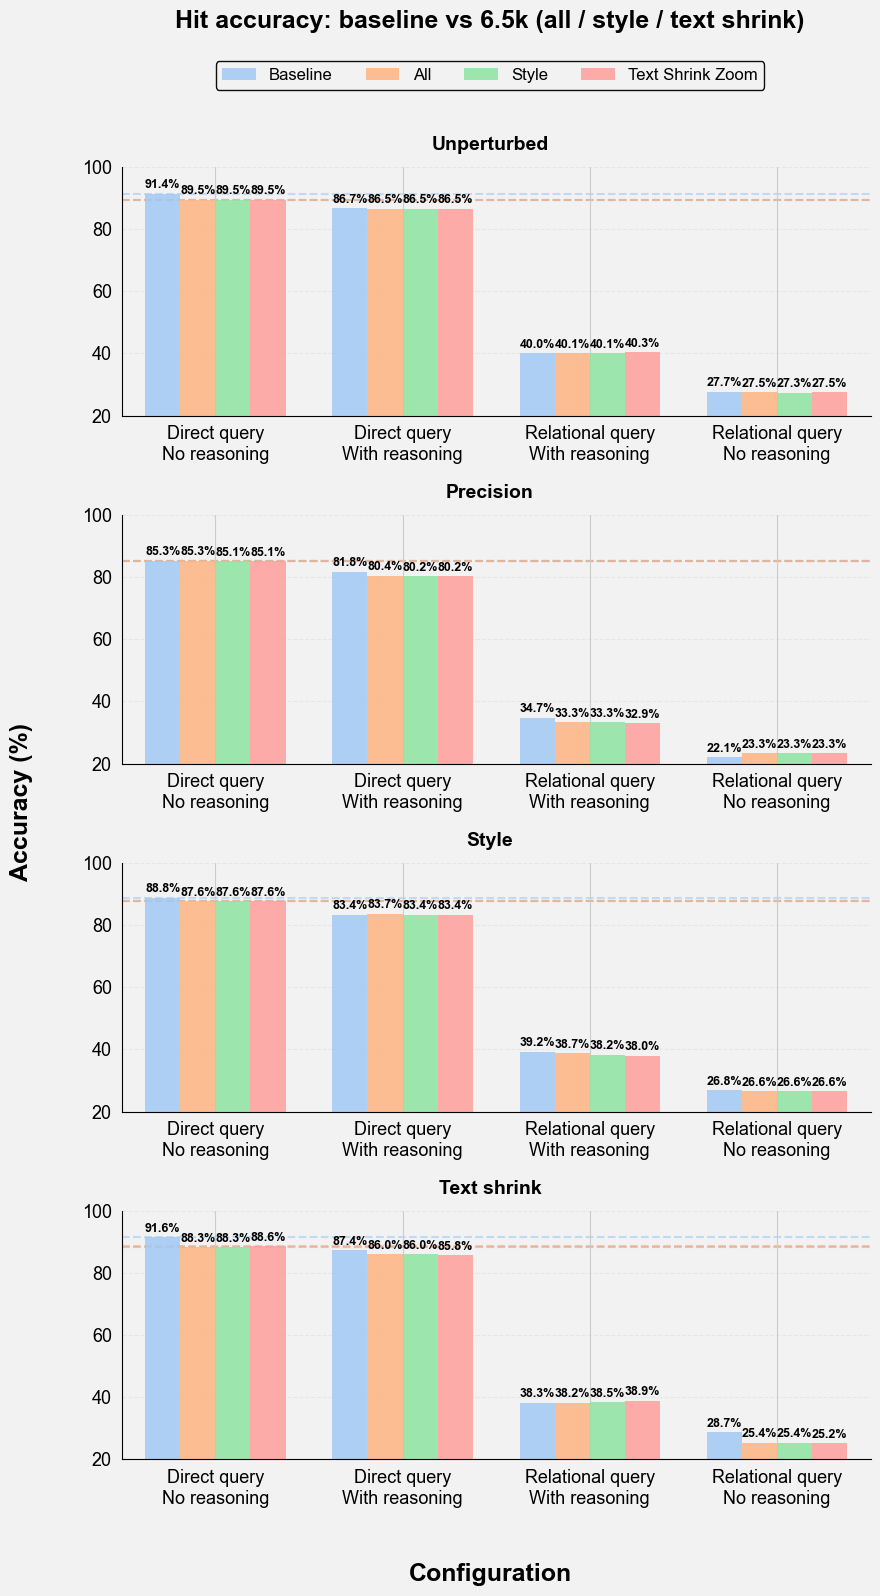

In [123]:
# PLOT: Baseline vs 6.5k all vs style vs text shrink — perturbation eval (shared logic)
plot_perturbation_grouped_bars(
    summary_df_plot1, models_plot1, model_color_dict_plot1,
    'Hit accuracy: baseline vs 6.5k (all / style / text shrink)'
)

# Scaling experiments

## baseline vs small data vs big data perturbation eval

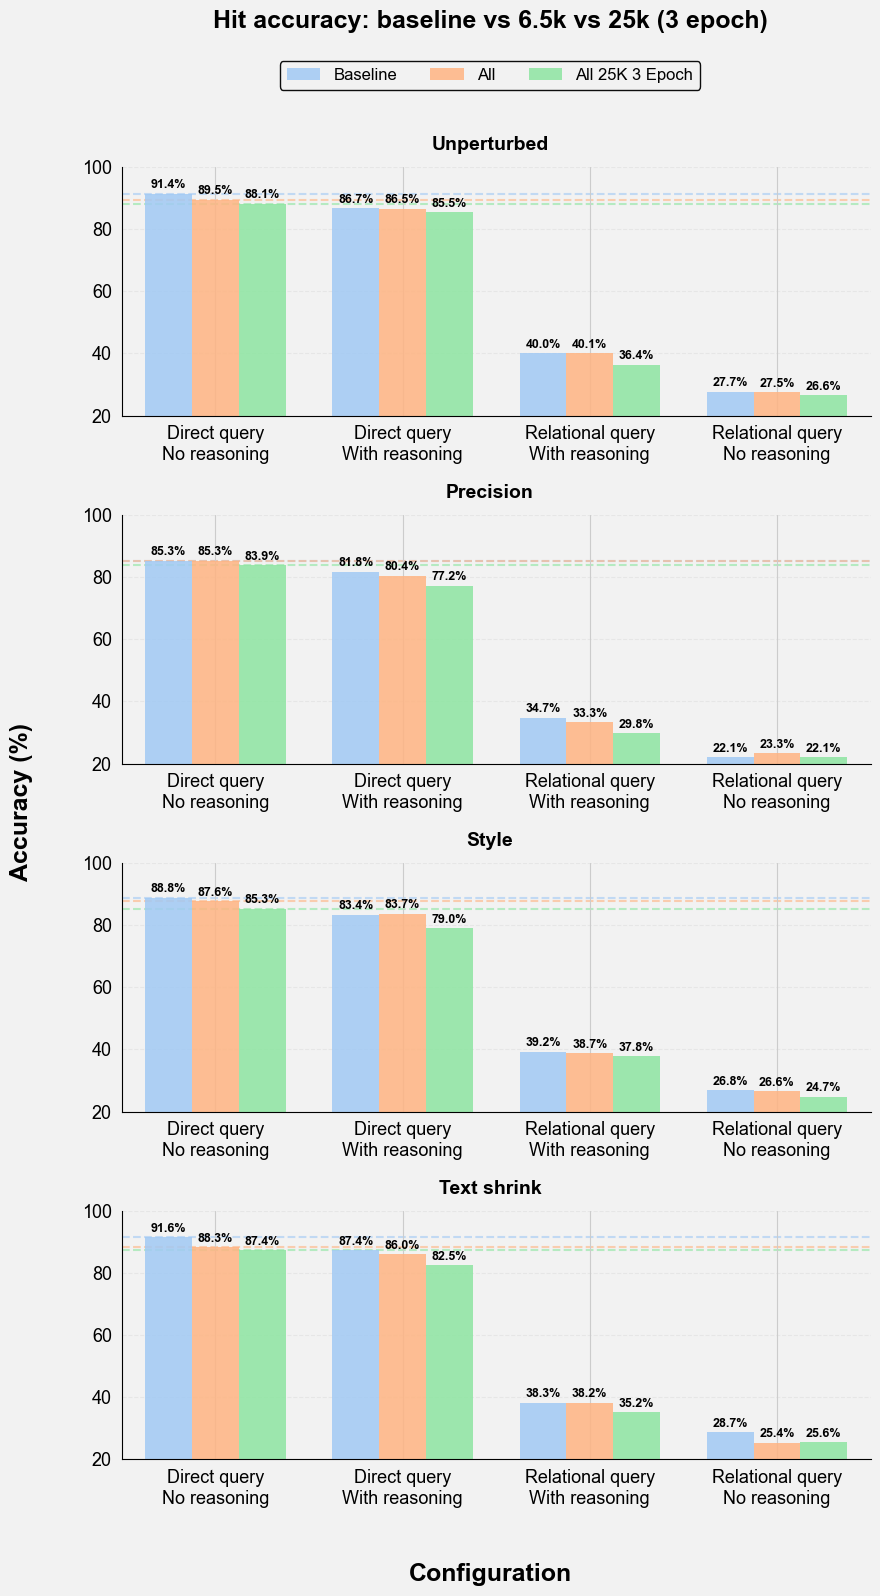

In [124]:
# PLOT: Baseline vs small data (6.5k all) vs big data (25k 3 epoch) — perturbation eval (shared logic)
plot_perturbation_grouped_bars(
    summary_df_plot2, models_plot2, model_color_dict_plot2,
    'Hit accuracy: baseline vs 6.5k vs 25k (3 epoch)'
)

## baseline vs small data vs big data screenspot-v2

ScreenSpot v2 overall (baseline vs 6.5k all vs 25k) — table uses all samples:


,run,action_acc,text_acc,icon_acc,num_correct_action,num_total
0,baseline,0.428852,0.460306,0.388087,3273,7632
1,6.5k all,0.424921,0.455432,0.385379,3243,7632
2,25k,0.421384,0.452646,0.380866,3216,7632


Plot below: positive (feasible) samples only; scores can be higher than the table.


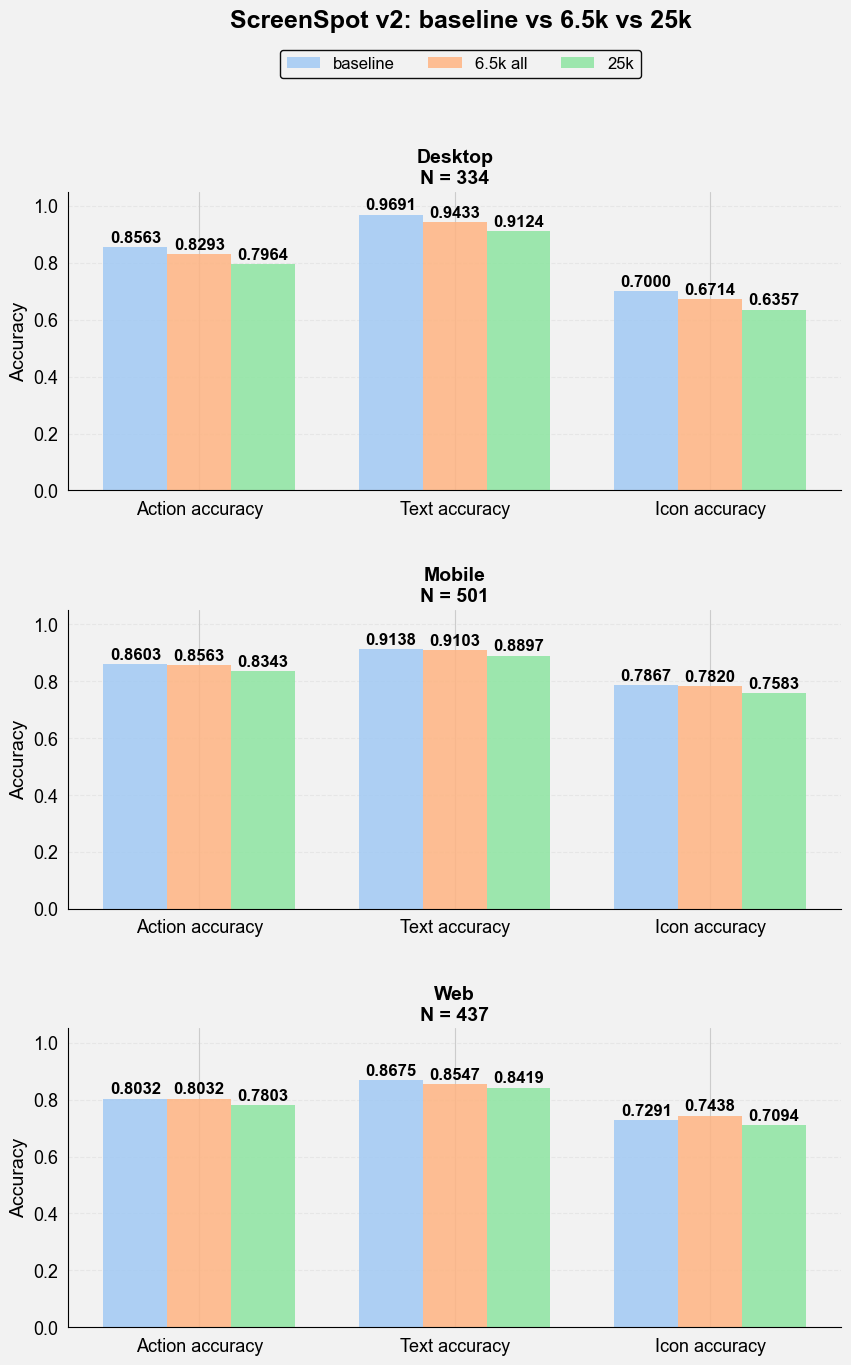

In [126]:
# ScreenSpot v2: baseline vs 6.5k all vs 25k — same style as baseline vs real vs synthetic
import json
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#f2f2f2", "axes.facecolor": "#f2f2f2",
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "legend.edgecolor": "black",
})

SCREENSPOT_DIR_6500_25K = Path("/Users/lockewang/FIG/WebDomainRandomizer/screenspot_results")
RUN_CONFIG_6500_25K = [
    ("baseline", SCREENSPOT_DIR_6500_25K / "uitars15_7b_screenspot_v2_all_baseline.json"),
    ("6.5k all", SCREENSPOT_DIR_6500_25K / "uitars15_7b_screenspot_v2_all_6500.json"),
    ("25k", SCREENSPOT_DIR_6500_25K / "uitars15_7b_screenspot_v2_25k_3_epoch_all_data.json"),
]
METRIC_COLUMNS_SS = ["action_acc", "text_acc", "icon_acc", "num_correct_action", "num_total", "wrong_format_num", "error_num", "wrong_num"]

def _load_metrics_ss(path):
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    return data.get("metrics", {})

def _flatten_metrics_ss(run_label, metrics, filter_negative=True):
    rows = []
    for cat_name, cat_data in metrics.items():
        if cat_name in ("overall", "overall_positive"):
            if isinstance(cat_data, dict) and any(k in cat_data for k in METRIC_COLUMNS_SS):
                row = {"run": run_label, "category": cat_name, "key": cat_name}
                for col in METRIC_COLUMNS_SS:
                    row[col] = cat_data.get(col)
                rows.append(row)
            continue
        if not isinstance(cat_data, dict):
            continue
        for key, value_dict in cat_data.items():
            if filter_negative and "gt_type:negative" in key:
                continue
            if not isinstance(value_dict, dict):
                continue
            row = {"run": run_label, "category": cat_name, "key": key}
            for col in METRIC_COLUMNS_SS:
                row[col] = value_dict.get(col)
            rows.append(row)
    return rows

def _parse_fine_grained_key_ss(key):
    out = {"platform": "", "instruction_style": "", "gt_type": ""}
    for part in key.split():
        if ":" in part:
            k, v = part.split(":", 1)
            if k == "plat": out["platform"] = v
            elif k == "inst_style": out["instruction_style"] = v
            elif k == "gt_type": out["gt_type"] = v
    return out

def _leaderboard_detailed_ss(df, run_config, metric="action_acc", runs_order=None, include_negative=False):
    fine = df[df["category"] == "fine_grained"].copy()
    if fine.empty:
        return pd.DataFrame()
    parsed = fine["key"].apply(_parse_fine_grained_key_ss)
    fine["platform"] = [p["platform"] for p in parsed]
    fine["gt_type"] = [p["gt_type"] for p in parsed]
    if not include_negative:
        fine = fine[fine["gt_type"] == "positive"]
    if fine.empty:
        return pd.DataFrame()
    runs_order = runs_order or [r for r, _ in run_config if r in fine["run"].values]
    pivot = fine.pivot_table(index=["platform", "gt_type"], columns="run", values=metric, aggfunc="first")
    return pivot.reindex(columns=runs_order)

def _add_sample_size_ss(pivot_df, full_df, index_names):
    fine = full_df[full_df["category"] == "fine_grained"].copy()
    if fine.empty:
        return pivot_df
    parsed = fine["key"].apply(_parse_fine_grained_key_ss)
    fine["platform"] = [p["platform"] for p in parsed]
    fine["gt_type"] = [p["gt_type"] for p in parsed]
    keys = [k for k in index_names if k in fine.columns]
    if not keys:
        return pivot_df
    n_per = fine.groupby(keys)["num_total"].first()
    out = pivot_df.copy()
    out.insert(0, "N", pivot_df.index.map(lambda idx: n_per.get(idx, None)))
    return out

def plot_screenspot_v2_three_rows(screenspot_df, runs_order, run_colors, overall_df, n_total, suptitle, parse_key_func, label_offset=0.006, legend_y=0.94, rect_top=0.94):
    """Shared 3 rows x 1 column plot: each row = platform (Desktop/Mobile/Web), x = metrics, grouped bars = runs.
    Uses fine_grained data with positive (feasible) samples only.
    Legend/subplot gap: lower legend_y = legend closer to subplots; higher rect_top = subplot area extends higher (less gap)."""
    fine = screenspot_df[screenspot_df["category"] == "fine_grained"].copy()
    if fine.empty:
        fig, ax = plt.subplots(1, 1, figsize=(8, 4), facecolor="#f2f2f2")
        ax.set_facecolor("#f2f2f2")
        metric_titles = ["Action accuracy", "Text accuracy", "Icon accuracy"]
        n_runs = len(runs_order)
        total_bar_span = 0.75
        width = total_bar_span / n_runs
        x_pos = np.arange(3)
        bar_positions = [x_pos - (n_runs - 1) / 2 * width + i * width for i in range(n_runs)]
        for run_idx, run in enumerate(runs_order):
            row = overall_df[overall_df["run"] == run]
            vals = [row["action_acc"].iloc[0], row["text_acc"].iloc[0], row["icon_acc"].iloc[0]] if len(row) > 0 else [0, 0, 0]
            vals = [float(v) if not pd.isna(v) else 0.0 for v in vals]
            ax.bar(bar_positions[run_idx], vals, width, label=run, color=run_colors[run], alpha=0.85, edgecolor="none")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(metric_titles, fontsize=14)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='both', labelsize=13)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3, linestyle="--", axis="y")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)
        fig.suptitle(suptitle, fontsize=18, fontweight='bold', y=0.995)
        plt.tight_layout(rect=[0.03, 0.02, 0.90, 0.94])
        plt.show()
        return
    parsed = fine["key"].apply(parse_key_func)
    fine["platform"] = [p["platform"] for p in parsed]
    fine["gt_type"] = [p["gt_type"] for p in parsed]
    fine = fine[fine["gt_type"] == "positive"]
    metric_titles = ["Action accuracy", "Text accuracy", "Icon accuracy"]
    n_runs = len(runs_order)
    total_bar_span = 0.75
    width = total_bar_span / n_runs
    platforms = sorted(fine["platform"].unique().tolist())[:3]
    fig, axes = plt.subplots(3, 1, figsize=(10, 14), facecolor="#f2f2f2")
    axes = np.atleast_1d(axes).flatten()
    for ax in axes:
        ax.set_facecolor("#f2f2f2")
        ax.grid(True, alpha=0.3, linestyle="--", axis="y")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)
    for idx, platform in enumerate(platforms):
        if idx >= 3:
            break
        ax = axes[idx]
        plat_df = fine[fine["platform"] == platform]
        x_pos = np.arange(3)
        bar_positions = [x_pos - (n_runs - 1) / 2 * width + i * width for i in range(n_runs)]
        for run_idx, run in enumerate(runs_order):
            row = plat_df[plat_df["run"] == run]
            if row.empty:
                vals = [0.0, 0.0, 0.0]
            else:
                r = row.iloc[0]
                vals = [r.get("action_acc", 0) or 0, r.get("text_acc", 0) or 0, r.get("icon_acc", 0) or 0]
            vals = [float(v) if not pd.isna(v) else 0.0 for v in vals]
            b = ax.bar(bar_positions[run_idx], vals, width, label=run, color=run_colors[run], alpha=0.85, edgecolor="none")
            for bar, v in zip(b, vals):
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + label_offset, f"{v:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(metric_titles, fontsize=14)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='both', labelsize=13)
        ax.set_ylabel("Accuracy", fontsize=14)
        n_val = plat_df["num_total"].iloc[0] if "num_total" in plat_df.columns and len(plat_df) and not pd.isna(plat_df["num_total"].iloc[0]) else None
        ax.set_title(f"{platform.title()}\nN = {int(n_val)}" if n_val is not None else platform.title(), fontsize=14, fontweight="bold")
    fig.suptitle(suptitle, fontsize=18, fontweight='bold', y=0.995)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=n_runs, loc='lower center', bbox_to_anchor=(0.5, legend_y), fontsize=12, framealpha=0.95)
    plt.tight_layout(rect=[0.03, 0.02, 0.90, rect_top])
    plt.subplots_adjust(hspace=0.4)
    plt.show()

all_rows_6500_25k = []
for run_label, path in RUN_CONFIG_6500_25K:
    if not path.exists():
        print(f"Skip (not found): {path}")
        continue
    metrics = _load_metrics_ss(path)
    all_rows_6500_25k.extend(_flatten_metrics_ss(run_label, metrics, filter_negative=True))

screenspot_df_6500_25k = pd.DataFrame(all_rows_6500_25k)
if screenspot_df_6500_25k.empty:
    print("No ScreenSpot v2 data loaded for baseline vs 6.5k all vs 25k.")
else:
    runs_order_6500_25k = [r for r, _ in RUN_CONFIG_6500_25K if r in screenspot_df_6500_25k["run"].values]
    if not runs_order_6500_25k:
        runs_order_6500_25k = screenspot_df_6500_25k["run"].unique().tolist()
    run_colors_6500_25k = {r: sns.color_palette("pastel", n_colors=len(runs_order_6500_25k))[i] for i, r in enumerate(runs_order_6500_25k)}

    if "overall_positive" in screenspot_df_6500_25k["category"].values:
        overall_6500_25k = screenspot_df_6500_25k[screenspot_df_6500_25k["category"] == "overall_positive"].copy()
    else:
        overall_6500_25k = screenspot_df_6500_25k[screenspot_df_6500_25k["category"] == "overall"].copy()
    cols_ss = ["run", "action_acc", "text_acc", "icon_acc", "num_correct_action", "num_total"]
    overall_df_6500_25k = overall_6500_25k[[c for c in cols_ss if c in overall_6500_25k.columns]].drop_duplicates(subset=["run"])
    overall_df_6500_25k = overall_df_6500_25k.set_index("run").reindex(runs_order_6500_25k).reset_index()
    print("ScreenSpot v2 overall (baseline vs 6.5k all vs 25k) — table uses all samples:")
    display(overall_df_6500_25k)
    n_total_6500_25k = int(overall_df_6500_25k["num_total"].max()) if "num_total" in overall_df_6500_25k.columns and len(overall_df_6500_25k) else None
    print("Plot below: positive (feasible) samples only; scores can be higher than the table.")

    suptitle = "ScreenSpot v2: baseline vs 6.5k vs 25k"
    plot_screenspot_v2_three_rows(screenspot_df_6500_25k, runs_order_6500_25k, run_colors_6500_25k, overall_df_6500_25k, n_total_6500_25k, suptitle, _parse_fine_grained_key_ss)



## baseline vs real vs synthetic data finetuning perturbation eval

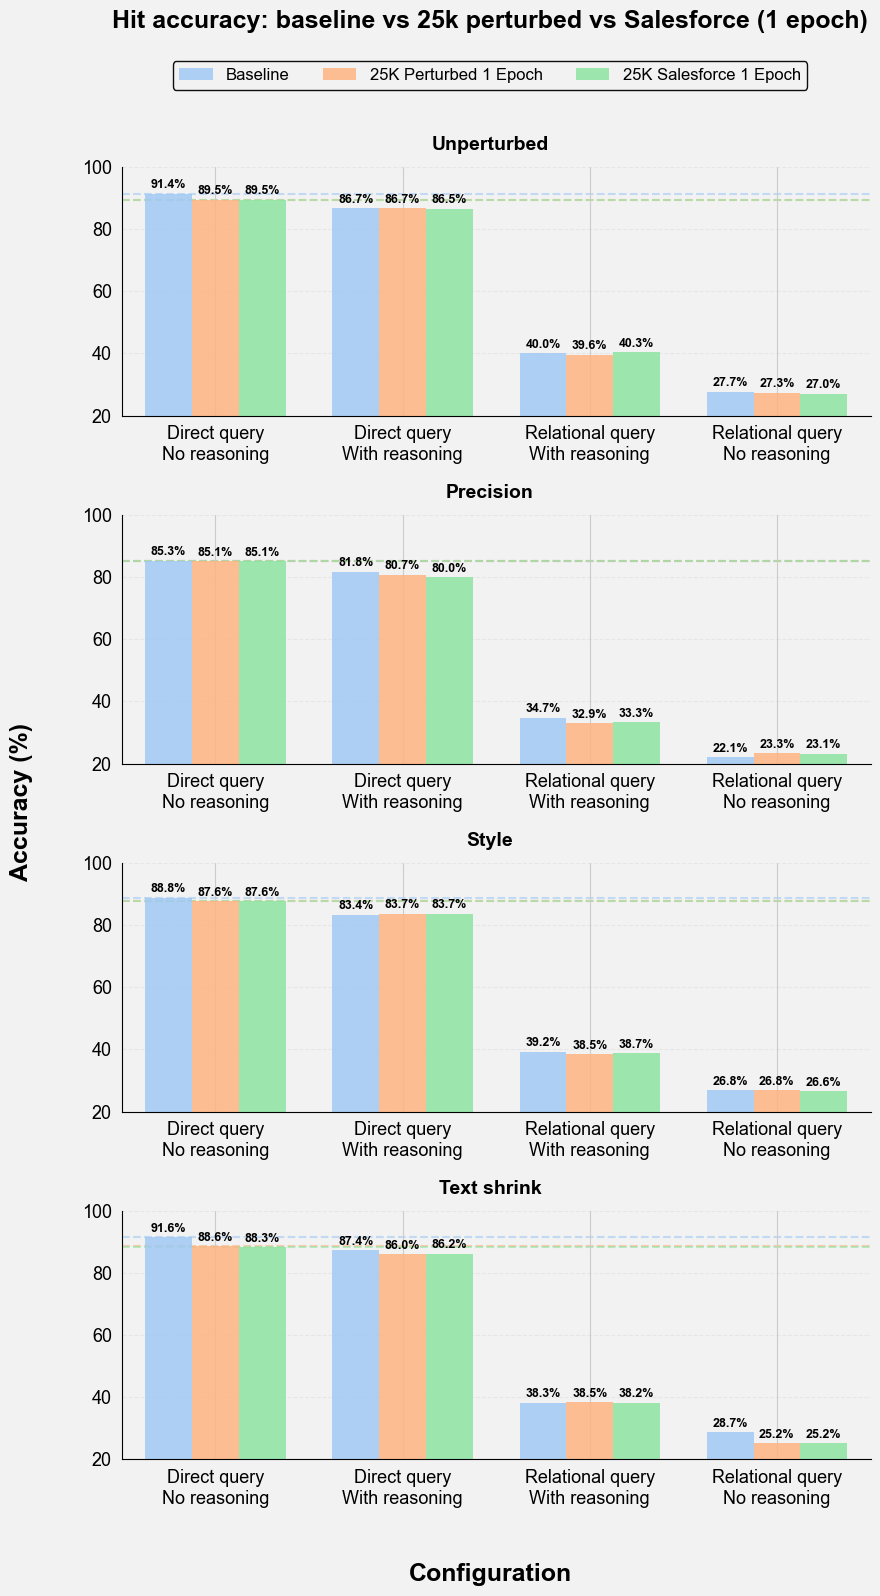

In [128]:
# PLOT: Baseline vs 25k perturbed vs 25k salesforce (real vs synthetic) — same grouped bar style
plot_perturbation_grouped_bars(
    summary_df_plot3, models_plot3, model_color_dict_plot3,
    'Hit accuracy: baseline vs 25k perturbed vs Salesforce (1 epoch)'
)



## real vs synthetic data finetuning screenspot-v2

ScreenSpot v2 overall (baseline vs real vs synthetic) — table uses all samples:


,run,action_acc,text_acc,icon_acc,num_correct_action,num_total
0,baseline,0.428852,0.460306,0.388087,3273,7632
1,salesforce (real),0.424528,0.454735,0.385379,3240,7632
2,perturbed mind2web (synthetic),0.425314,0.455432,0.386282,3246,7632


Plot below: positive (feasible) samples only; scores can be higher than the table.


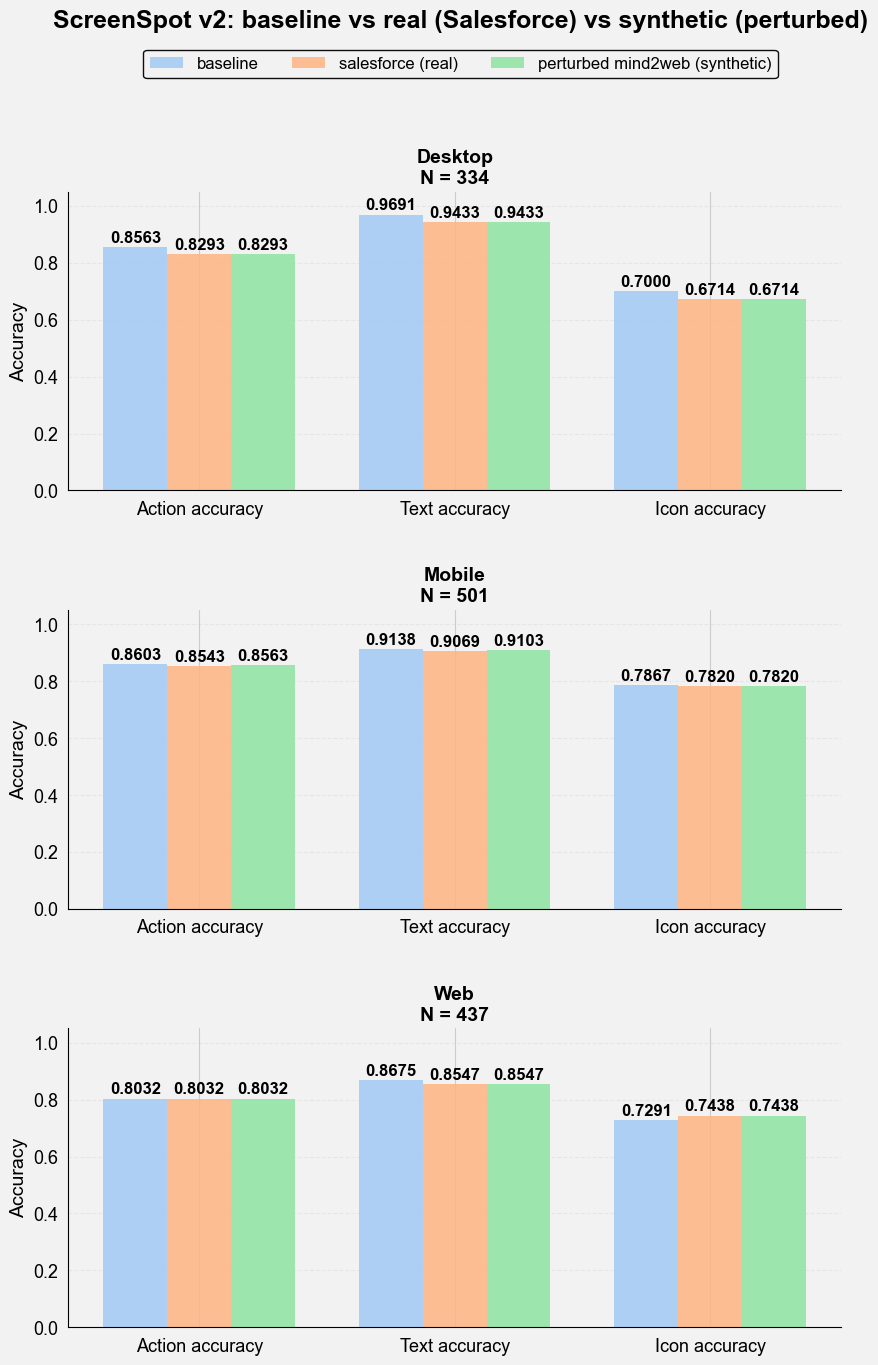

In [129]:
# ScreenSpot v2: baseline vs real (salesforce) vs synthetic (perturbed mind2web) — leaderboard style (aligned with notebook + official detailed logic)
import json
from pathlib import Path

# Match notebook plot style (whitegrid, pastel, black text, #f2f2f2 face)
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#f2f2f2", "axes.facecolor": "#f2f2f2",
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "legend.edgecolor": "black",
})

SCREENSPOT_DIR = Path("/Users/lockewang/FIG/WebDomainRandomizer/screenspot_results")
RUN_CONFIG = [
    ("baseline", SCREENSPOT_DIR / "uitars15_7b_screenspot_v2_all_baseline.json"),
    ("salesforce (real)", SCREENSPOT_DIR / "uitars15_7b_screenspot_v2_exp2.json"),
    ("perturbed mind2web (synthetic)", SCREENSPOT_DIR / "screenspot_v2_25k_all_perturbed_1_epoch_results.json"),
]
METRIC_COLUMNS = ["action_acc", "text_acc", "icon_acc", "num_correct_action", "num_total", "wrong_format_num", "error_num", "wrong_num"]

def _load_metrics(file_path):
    with open(file_path, encoding="utf-8") as f:
        data = json.load(f)
    return data.get("metrics", {})

def _flatten_metrics_for_run(run_label, metrics, filter_negative=True):
    rows = []
    for cat_name, cat_data in metrics.items():
        if cat_name in ("overall", "overall_positive"):
            if isinstance(cat_data, dict) and any(k in cat_data for k in METRIC_COLUMNS):
                row = {"run": run_label, "category": cat_name, "key": cat_name}
                for col in METRIC_COLUMNS:
                    row[col] = cat_data.get(col)
                rows.append(row)
            continue
        if not isinstance(cat_data, dict):
            continue
        for key, value_dict in cat_data.items():
            if filter_negative and "gt_type:negative" in key:
                continue
            if not isinstance(value_dict, dict):
                continue
            row = {"run": run_label, "category": cat_name, "key": key}
            for col in METRIC_COLUMNS:
                row[col] = value_dict.get(col)
            rows.append(row)
    return rows

# Official detailed leaderboard helpers (from screenspot_v2_leaderboard.py)
def _parse_fine_grained_key(key):
    out = {"platform": "", "instruction_style": "", "gt_type": ""}
    for part in key.split():
        if ":" in part:
            k, v = part.split(":", 1)
            if k == "plat":
                out["platform"] = v
            elif k == "inst_style":
                out["instruction_style"] = v
            elif k == "gt_type":
                out["gt_type"] = v
    return out

def _get_fine_grained_detailed(df):
    fine = df[df["category"] == "fine_grained"].copy()
    if fine.empty:
        return fine
    parsed = fine["key"].apply(_parse_fine_grained_key)
    fine["platform"] = [p["platform"] for p in parsed]
    fine["instruction_style"] = [p["instruction_style"] for p in parsed]
    fine["gt_type"] = [p["gt_type"] for p in parsed]
    return fine

def _leaderboard_detailed_style(df, metric="action_acc", runs_order=None, include_negative=False):
    fine = df[df["category"] == "fine_grained"].copy()
    if fine.empty:
        return pd.DataFrame()
    parsed = fine["key"].apply(_parse_fine_grained_key)
    fine["platform"] = [p["platform"] for p in parsed]
    fine["gt_type"] = [p["gt_type"] for p in parsed]
    if not include_negative:
        fine = fine[fine["gt_type"] == "positive"]
    if fine.empty:
        return pd.DataFrame()
    runs_order = runs_order or [r for r, _ in RUN_CONFIG if r in fine["run"].values]
    pivot = fine.pivot_table(index=["platform", "gt_type"], columns="run", values=metric, aggfunc="first")
    return pivot.reindex(columns=runs_order)

def _add_sample_size_column(pivot_df, full_df, index_names):
    fine = full_df[full_df["category"] == "fine_grained"].copy()
    if fine.empty:
        return pivot_df
    parsed = fine["key"].apply(_parse_fine_grained_key)
    fine["platform"] = [p["platform"] for p in parsed]
    fine["gt_type"] = [p["gt_type"] for p in parsed]
    keys = [k for k in index_names if k in fine.columns]
    if not keys:
        return pivot_df
    n_per = fine.groupby(keys)["num_total"].first()
    out = pivot_df.copy()
    out.insert(0, "N", pivot_df.index.map(lambda idx: n_per.get(idx, None)))
    return out

all_rows = []
for run_label, path in RUN_CONFIG:
    if not path.exists():
        print(f"Skip (not found): {path}")
        continue
    metrics = _load_metrics(path)
    all_rows.extend(_flatten_metrics_for_run(run_label, metrics, filter_negative=True))

screenspot_df = pd.DataFrame(all_rows)
if screenspot_df.empty:
    print("No ScreenSpot v2 data loaded.")
else:
    runs_order = [r for r, _ in RUN_CONFIG if r in screenspot_df["run"].values]
    if not runs_order:
        runs_order = screenspot_df["run"].unique().tolist()
    run_colors = {r: sns.color_palette("pastel", n_colors=len(runs_order))[i] for i, r in enumerate(runs_order)}
    label_offset = 0.02

    # --- Overall summary + plot (same style as above grouped bars) ---
    if "overall_positive" in screenspot_df["category"].values:
        overall = screenspot_df[screenspot_df["category"] == "overall_positive"].copy()
    else:
        overall = screenspot_df[screenspot_df["category"] == "overall"].copy()
    cols = ["run", "action_acc", "text_acc", "icon_acc", "num_correct_action", "num_total"]
    overall_df = overall[[c for c in cols if c in overall.columns]].drop_duplicates(subset=["run"])
    overall_df = overall_df.set_index("run").reindex(runs_order).reset_index()
    print("ScreenSpot v2 overall (baseline vs real vs synthetic) — table uses all samples:")
    display(overall_df)
    n_total = int(overall_df["num_total"].max()) if "num_total" in overall_df.columns and len(overall_df) else None
    print("Plot below: positive (feasible) samples only; scores can be higher than the table.")

    suptitle = "ScreenSpot v2: baseline vs real (Salesforce) vs synthetic (perturbed)"

    plot_screenspot_v2_three_rows(screenspot_df, runs_order, run_colors, overall_df, n_total, suptitle, _parse_fine_grained_key)